In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight


In [23]:
# get path to root dataset 
dataset_dir = Path("../data/Crop_Disease" )
# 
full_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    label_mode='categorical',      
    image_size=(224, 224),          
    batch_size=32,
    shuffle=True
)

Found 13324 files belonging to 5 classes.


This method of loading images using `tf.keras.utils.image_dataset_from_directory` is preferred because it creates a **ready-to-train TensorFlow dataset** directly from a directory of labeled images, avoiding the need to manually read, resize, or batch images. The function automatically assigns labels based on subfolder names, converts them to one-hot vectors when `label_mode='categorical'` is specified, resizes all images to a consistent shape `(224, 224)`, batches them into manageable sizes (32 images per batch), and shuffles the dataset for unbiased training. Shuffling randomizes the order of images in each epoch so that each batch contains a mix of classes, preventing the model from learning patterns based on the sequence of data and ensuring stable, generalized training. The resulting `tf.data.Dataset` object yields tuples of `(images, labels)`, where `images` are **actual image tensors** of shape `(batch_size, height, width, channels)` and `labels` are one-hot encoded vectors of shape `(batch_size, num_classes)`. These image tensors are fully decoded and ready for input into a neural network, eliminating the need for further file I/O or preprocessing and ensuring memory-efficient, scalable, and reproducible data pipelines.


## EDA

# Class Distribution


In [24]:
# get class names : How many crops are we dealing with 
class_names = full_ds.class_names
print(class_names)

['Corn', 'Potato', 'Rice', 'Wheat', 'sugarcane']


The dataset contains images from five different crops: Corn, Potato, Rice, Wheat, and Sugarcane.

Total images found: 13324
Class
Sugarcane_Healthy              100
Sugarcane_Bacterial Blight     100
Sugarcane_Red Rot              100
Potato_Healthy                 152
Corn_Gray_Leaf_Spot            513
Rice_Brown_Spot                613
Wheat_Brown_Rust               902
Wheat_Yellow_Rust              924
Rice_Leaf_Blast                977
Corn_Northern_Leaf_Blight      985
Rice_Neck_Blast               1000
Potato_Late_Blight            1000
Potato_Early_Blight           1000
Wheat_Healthy                 1116
Corn_Healthy                  1162
Corn_Common_Rust              1192
Rice_Healthy                  1488
Name: count, dtype: int64


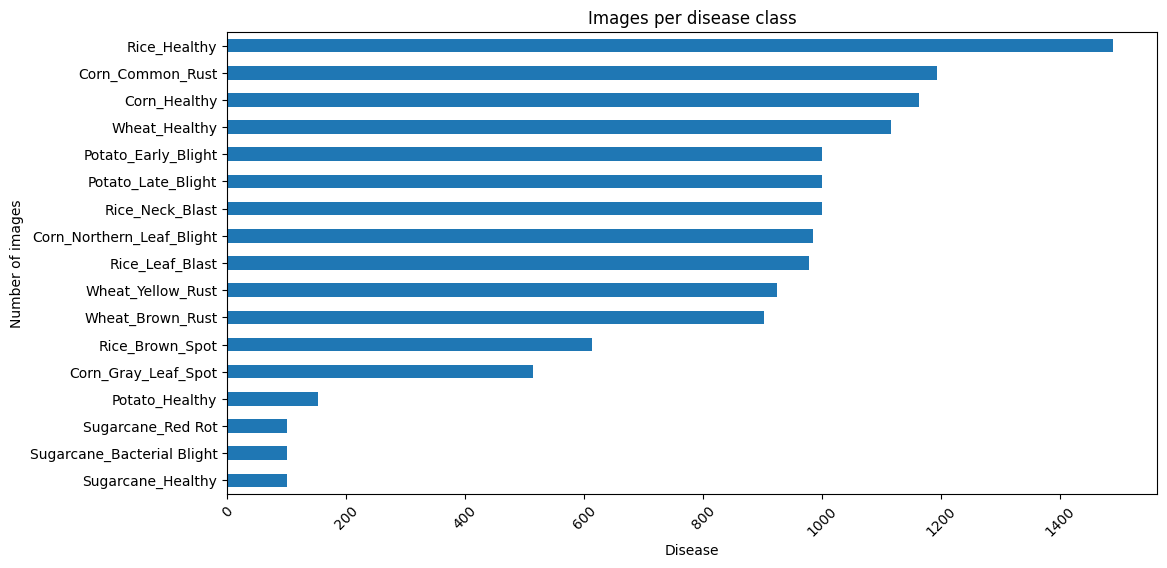

In [25]:
## Count images per class
# select all jpg/jpeg images recursively
all_files = list(dataset_dir.glob("**/*.[jJ][pP][gG]"))
print(f"Total images found: {len(all_files)}")

# Get class labels from parent folder names
all_labels = [f.parent.name for f in all_files]
df_labels = pd.DataFrame(all_labels, columns=['Class'])

# Count images per class
class_counts = df_labels['Class'].value_counts().sort_values(ascending=True)
print(class_counts)

# Visualize
plt.figure(figsize=(12,6))
class_counts.plot(kind='barh')
plt.xlabel("Disease")
plt.ylabel("Number of images")
plt.title("Images per disease class")
plt.xticks(rotation=45)
plt.show()

The dataset exhibits a moderate class imbalance across disease categories, with image counts ranging from as low as 100 (`Healthy`, `Bacterial Blight`, `Red Rot`) to as high as 1488 (`Rice___Healthy`). Most disease classes fall within the 900–1200 range, indicating a relatively consistent representation for several categories, but a few classes are significantly underrepresented. This imbalance may bias the model toward well-represented classes such as `Rice___Healthy` and `Corn___Common_Rust`, while reducing its ability to generalize to minority classes. Addressing this disparity is important to ensure balanced model performance across all disease categories.


# Image shapes 

In [26]:
for images, labels in full_ds.take(1):
    print("Batch shape:", images.shape)
    print("Label shape:", labels.shape)

Batch shape: (32, 224, 224, 3)
Label shape: (32, 5)


The results indicate that each batch contains 32 images, with each image resized to 224×224 pixels and represented using three color channels (RGB), while the labels are encoded as vectors of length five corresponding to the five crop classes. This confirms that the dataset structure aligns with the parameters specified in the Keras loading function, namely `image_size=(224, 224)`, `batch_size=32`, and `label_mode='categorical'`. A batch is a subset of the dataset processed together during one step of training, allowing the model to learn efficiently without loading the entire dataset into memory at once. Using a batch size of 32 ensures manageable memory usage, enables efficient parallel computation, and provides more stable gradient updates during training.


# Image Visualization
The image visualization serves as a sanity check on the dataset before training. It allows verification that images are correctly loaded, resized, and labeled. By inspecting a sample, it becomes possible to confirm that the labels correspond to the actual image content, detect mislabeled or irrelevant images, and identify any preprocessing issues such as distortion, incorrect scaling, or color anomalies. It also provides a quick understanding of the variability and quality of the data across classes. This step reduces the risk of training a model on flawed or inconsistent data, which would negatively affect performance.


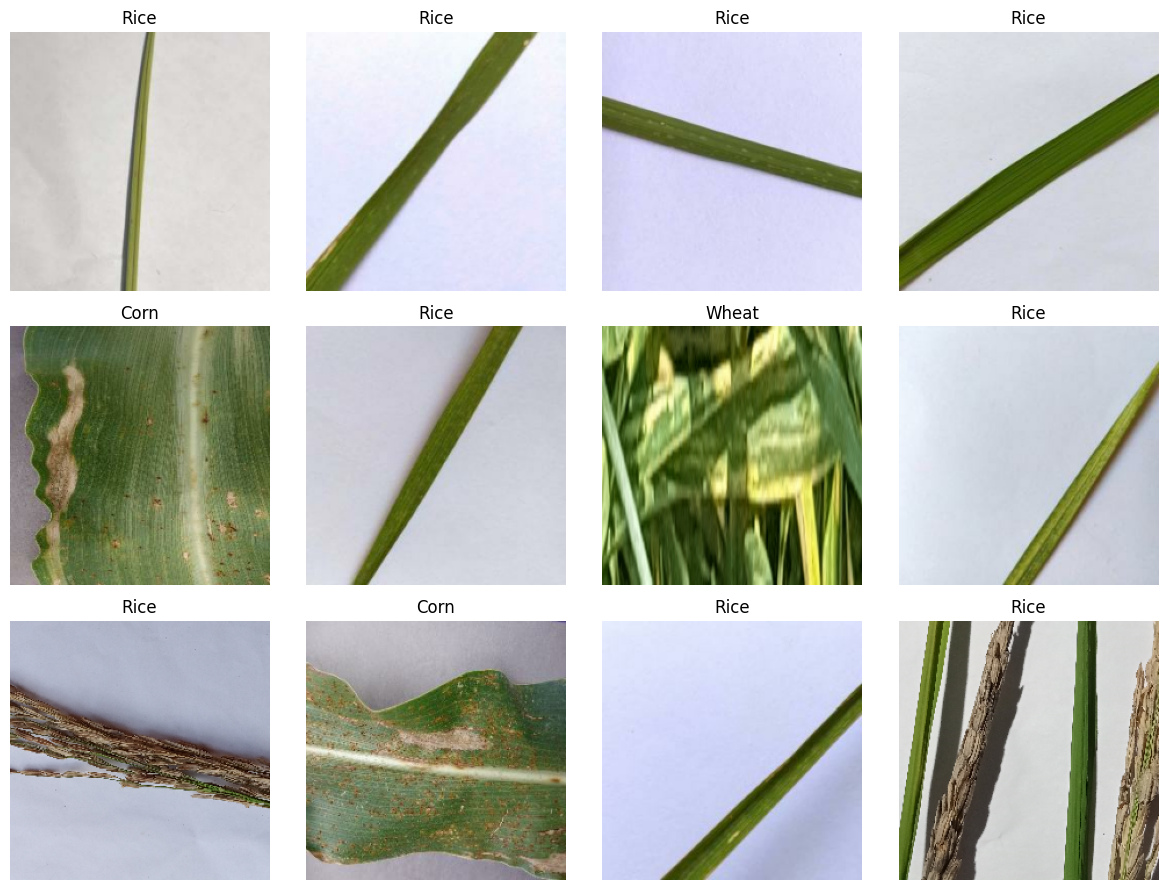

In [27]:
plt.figure(figsize=(12, 9))

for images, labels in full_ds.take(1):  # one batch
    for i in range(12):  # 3 rows × 4 columns
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_index])
        plt.axis("off")

plt.tight_layout()
plt.savefig("image_sample.png")
plt.show()

The plot visualizes the sample of images from one batch in a grid format for visual inspection. A figure of size 12×9 is created, and `full_ds.take(1)` retrieves a single batch of images and labels from the dataset. Within that batch, the loop selects the first 12 images and places them into a 3×4 grid using `plt.subplot(3, 4, i + 1)`. Each image tensor is converted to a displayable format with `.numpy().astype("uint8")`, and the corresponding label is obtained by taking the index of the highest value in the one-hot encoded vector using `tf.argmax(labels[i])`. The class name is then used as the title, and axes are turned off for clarity. Finally, the layout is adjusted, saved as an image file, and displayed.

The images change each time the code is run because the dataset was created with `shuffle=True`. This causes the order of images to be randomized every time the dataset is iterated, so each call to `full_ds.take(1)` returns a different batch. As a result, the subset of images visualized in the grid varies across executions.


In [28]:
for images, _ in full_ds.take(1):
    print("Min pixel value:", images.numpy().min())
    print("Max pixel value:", images.numpy().max())
    print("Mean pixel value:", images.numpy().mean())

Min pixel value: 0.0
Max pixel value: 255.0
Mean pixel value: 144.74913


In [29]:
#array stores all valid images 
valid_images = []
for path in dataset_dir.glob("**/*.[jJ][pP][gG]"):
    try:
        img = Image.open(path)
        img.verify()
        valid_images.append(path)
    except:
        print("Corrupt image:", path)

len(valid_images)

13324

Validation checks is done on the image dataset to identify and filter out corrupted files. Process begins by initializing an empty list, `valid_images`, which will store the paths of images that pass integrity checks. Then recursively selection of all files in the dataset directory is done using `dataset_dir.glob("**/*.[jJ][pP][gG]")`, which locates all files with `.jpg` or `.jpeg` extensions regardless of case and across all subdirectories. For each image path, the python attempts to open the file using the Python Imaging Library (PIL). The `img.verify()` method is then applied to confirm whether the file is a structurally valid image by checking its header and format consistency without fully decoding the image into memory. If the image passes this verification step, its path is added to the `valid_images` list. If an issue arises during opening or verification of an image file, its highlighted as corrupt, incomplete, or not a valid image. It's file path is printed for inspection. Finally, `len(valid_images)` returns the total number of images that successfully passed the integrity check (13,324, matching the total dataset size, confirming no corrupted images.), providing a quantitative measure of usable data within the dataset.


## Preprocessing 


### 1. Class weights.
Class weights make the model penalize misclassifications of underrepresented classes more heavily than those of abundant classes, forcing balanced learning across all categories.

In [30]:

# class names in same order as model output
class_names = [
    "Sugarcane_Healthy", "Sugarcane_Bacterial Blight", "Sugarcane_Red Rot",
    "Potato_Healthy", "Corn_Gray_Leaf_Spot", "Rice_Brown_Spot",
    "Wheat_Brown_Rust", "Wheat_Yellow_Rust", "Rice_Leaf_Blast",
    "Corn_Northern_Leaf_Blight", "Rice_Neck_Blast", "Potato_Late_Blight",
    "Potato_Early_Blight", "Wheat_Healthy", "Corn_Healthy",
    "Corn_Common_Rust", "Rice_Healthy"
]

# counts from your EDA
counts = np.array([
    100, 100, 100, 152, 513, 613, 902, 924, 977,
    985, 1000, 1000, 1000, 1116, 1162, 1192, 1488
])

# generate labels list
labels = np.concatenate([[i]*count for i, count in enumerate(counts)])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=labels
)

class_weights = dict(enumerate(class_weights))

The class weights output reflects the imbalance in the dataset by assigning a higher weight to classes with fewer images and a lower weight to those with many samples. For example, the `sugarcane disease classes`, which contain only about `100` images each, receive the highest weights, while dominant classes like `Rice_Healthy` with `1,488` images receive the lowest.

To generate these weights, the code first constructs a label array where each image is represented by its class index, repeated according to the number of images in that class. This array captures the frequency distribution of all classes. The `compute_class_weight` function then takes this label array and calculates a weight for each class, assigning higher values to underrepresented classes and lower values to majority classes. Finally, the weights are stored in a dictionary mapping each class index to its corresponding weight, which is used during training to scale the loss contribution of each sample, ensuring balanced learning across all categories.

This weighting ensures that during model training, errors on underrepresented classes have a proportionally larger impact on the loss function (errors from underpresented classes are penalized more), preventing the model from biasing toward majority classes. Without these weights, the model would tend to prioritize learning features from abundant classes, neglecting rare diseases. By scaling the contribution of each class to the loss, the network is encouraged to learn balanced feature representations across all diseases, improving predictive performance on both minority and majority classes. The weights are applied directly during training via the `class_weight` parameter in the model’s fit method, ensuring that each sample’s loss is scaled according to its class.

### 2.Data Augmentation
Data augmentation is applied to address limitations in the dataset, particularly class imbalance and insufficient variability in image samples. In this dataset, some disease classes have significantly fewer images than others, which can cause the model to bias its learning toward majority classes and fail to generalize well to underrepresented conditions. Additionally, real-world agricultural images can vary in orientation, lighting, and scale, which may not be fully captured in the original dataset.

In [31]:
# define augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

To mitigate these issues, data augmentation introduces controlled transformations such as `rotation`, `flipping`, `zooming`, and `translation`. These transformations do not create new stored images; instead, they generate modified versions of existing images dynamically during training. As a result, the dataset size remains unchanged, but the model is exposed to a wider range of variations for each class. This increases the effective diversity of the training data, improves robustness to real-world conditions, and reduces overfitting without requiring additional data collection.

In [32]:
# combine augmentation with preprocessing 
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

def preprocess(images, labels):
    images = data_augmentation(images, training=True)
    images = preprocess_input(images)
    return images, labels


In [33]:
# apply augmentation func to data 
train_ds = full_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
# original
for images, _ in full_ds.take(1):
    original = images[0].numpy()

# augmented
for images, _ in train_ds.take(1):
    augmented = images[0].numpy()



224
224


In [45]:
print(f"Original:", np.mean(original), "Augmented:", np.mean(augmented))

Original: 207.87735 Augmented: 71.55225
